# 1. Setup and Imports

In [ ]:
%%capture
!pip install langchain==0.2.5 langchain-community==0.2.5 langchain_openai>=0.1.6
!pip install openai>=1.13.3 transformers>=4.40.1 datasets>=2.18.0 accelerate>=0.27.2
!pip install sentence-transformers==3.0.1 duckduckgo-search>=5.2.2 cohere==5.5.8
!pip install faiss-cpu==1.8.0 rank_bm25==0.2.2
!pip install llama-cpp-python==0.2.78 --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124
# IMPORTANT: Make sure to restart the session after installing the packages above.

In [ ]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import faiss
import duckduckgo_search
import cohere
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import textwrap
from tqdm import tqdm
warnings.filterwarnings('ignore')


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.10.0+cu128
CUDA available: True


# 2. Data Loading and Inspection

### What is being done?
We are loading the official ag_news dataset from Huggingface, which is a large collection of news articles, that spans 4 major categories/labels: World, Sports, Business, and Science/Technology. We will treat each articles as an internal industry brief that a consulting firm might have on file.
Down below, we're going to inspect the data to understand its structure, size, and content.

### Why is this necessary from a business analytics perspective?
Before any analysis, the consultant, obviously, has to first understand the data they are working with. It's fundamentally the equivalent of doing your "homework" or due diligence before arriving at a solution.

As seen below, we're gonna focus on the Business and Science/technology labeled articles for our knowledge base.

### How should decision-makers interpret this?
The output confirms the volume and variety of the document collection. A larger, more diverse
corpus generally means the assistant can answer a wider range of questions, but also requires
more careful quality filtering.



In [ ]:
# load the ag_news dataset from Hugging Face
dataset = load_dataset("ag_news")["train"]

In [ ]:
# Explore dataset
print(f"Total documents in dataset: {len(dataset):,}")

#see cols
print(f"\nColumns available: {dataset.column_names}")

print(dataset)
print(dataset['text'])
print(dataset['label'])

Total documents in dataset: 120,000

Columns available: ['text', 'label']
Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
Column(["Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel m

In [ ]:
# map the integer labels into text lables
label_map = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Science/Technology'}
print(f"\nCategory labels: {label_map}")


Category labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Science/Technology'}


In [ ]:
# we're going to convert the raw dataset into a pandas DataFrame for easier handling & manipulation
df = pd.DataFrame(dataset)
df['category'] = df['label'].map(label_map)
df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


Document distribution by category:
category
Business              30000
Science/Technology    30000
Sports                30000
World                 30000


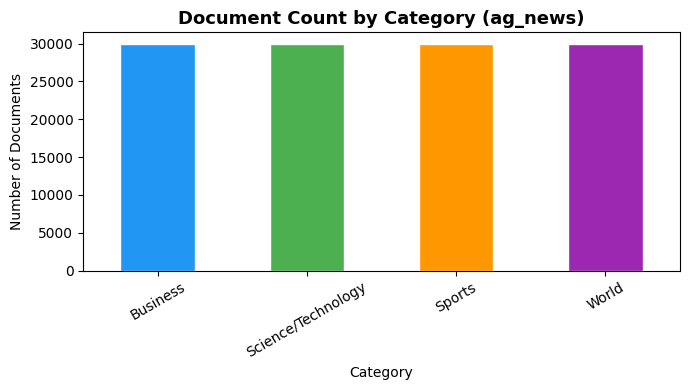

In [ ]:
# Show distribution across categories
print("Document distribution by category:")
print(df['category'].value_counts().to_string())

# Visualise the distribution
fig, ax = plt.subplots(figsize=(7, 4))
df['category'].value_counts().plot(
    kind='bar', ax=ax,
    color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
    edgecolor='white'
)
ax.set_title('Document Count by Category (ag_news)', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Documents')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

#### C: okay it's a well balanced dataset

In [ ]:
# Display 5 sample documents so stakeholders can see the raw content
print("=" * 70)
print("SAMPLE DOCUMENTS FROM THE KNOWLEDGE ARCHIVE")
print("=" * 70)

samples = df.sample(5, random_state=42)
for i, (_, row) in enumerate(samples.iterrows(), 1):
    print(f"\n[Document {i}] Category: {row['category']}")
    print("-" * 50)
    print(textwrap.fill(row['text'], width=80))
    print()

SAMPLE DOCUMENTS FROM THE KNOWLEDGE ARCHIVE

[Document 1] Category: Business
--------------------------------------------------
BBC set for major shake-up, claims newspaper London - The British Broadcasting
Corporation, the world #39;s biggest public broadcaster, is to cut almost a
quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year
history, The Times newspaper in London said on Monday.


[Document 2] Category: Business
--------------------------------------------------
Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive
clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh
amp; McLennan Cos.


[Document 3] Category: Sports
--------------------------------------------------
Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that
started with a terrible slump into one of the best in his accomplished 10-year
career.


[Document 4] Category: Science/Technology
-------------------------------

In [ ]:
# For this project we focus on Business and Science/Technology briefs
# as these are most relevant to a strategy consulting knowledge base.
# We sample 100 documents to keep runtime manageable (and to be able to use Cohere with my rate limits rip)
SAMPLE_SIZE  = 100
RANDOM_STATE = 42

df_subset = (
    df[df['category'].isin(['Business', 'Science/Technology'])]
    .sample(SAMPLE_SIZE, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Working corpus size: {len(df_subset):,} documents")
print(df_subset['category'].value_counts().to_string())

Working corpus size: 100 documents
category
Science/Technology    52
Business              48


# 3. Text Preprocessing

### What is being done?
We clean the raw document text to make it suitable for embedding and retrieval. Following
the same light-touch philosophy shown in the Chapter 8 reference notebook, we:
- Remove empty or near-empty documents
- Strip excess whitespace and newlines
- Normalise common encoding artifacts (e.g., `&amp;`)

We intentionally avoid aggressive transformations (stemming, lowercasing) because modern
embedding models perform best on natural, readable text.

### Why is this necessary from a business analytics perspective?
Garbage in, garbage out. Even a powerful AI model will return poor results if fed malformed
or incomplete text. Preprocessing ensures that documents fed into the system are clean,
complete, and meaningful — the same standard applied to any dataset before analysis.
It also prevents edge cases (e.g., blank documents) from corrupting the search index.

### How should decision-makers interpret this?
The before/after document counts show how many records were removed due to quality issues.
A small drop is normal and healthy. A large drop would signal a data quality problem that
should be investigated before deploying the system.


In [ ]:
def preprocess_text(text: str) -> str:
    """
    Light preprocessing:
    - Strip leading/trailing whitespace
    - Collapse multiple spaces and newlines
    - Remove common HTML/encoding artifacts
    """
    if not isinstance(text, str):
        return ''
    text = text.strip()
    # Collapse internal whitespace
    text = ' '.join(text.split())
    # Fix common encoding artifacts found in news datasets
    text = text.replace('&amp;', '&').replace('&lt;', '<').replace('&gt;', '>')
    return text

# Count before preprocessing
count_before = len(df_subset)

# Apply preprocessing
df_subset['clean_text'] = df_subset['text'].apply(preprocess_text)

# Drop documents shorter than 30 characters (near-empty after cleaning)
MIN_LENGTH = 30
df_clean = (
    df_subset[df_subset['clean_text'].str.len() >= MIN_LENGTH]
    .reset_index(drop=True)
)

count_after = len(df_clean)

print(f"Documents before preprocessing : {count_before:,}")
print(f"Documents after  preprocessing : {count_after:,}")
print(f"Documents removed              : {count_before - count_after}")

# Show a before/after example
print("\nBEFORE:")
print(repr(df_subset.loc[0, 'text'][:200]))
print("\nAFTER:")
print(repr(df_clean.loc[0, 'clean_text'][:200]))

Documents before preprocessing : 100
Documents after  preprocessing : 100
Documents removed              : 0

BEFORE:
'WPP Buys Grey Global for  #36;1.31 Billion (Reuters) Reuters - British advertising firm WPP has agreed\\to buy smaller U.S. rival Grey Global for  #36;1.31 billion,\\equally divided in cash and shares, '

AFTER:
'WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British advertising firm WPP has agreed\\to buy smaller U.S. rival Grey Global for #36;1.31 billion,\\equally divided in cash and shares, to'


#### C: It appears that the Hugging Face dataset is already clean

Document length statistics (characters):
count    100.0
mean     250.0
std       77.0
min      116.0
25%      211.8
50%      239.0
75%      264.5
max      672.0


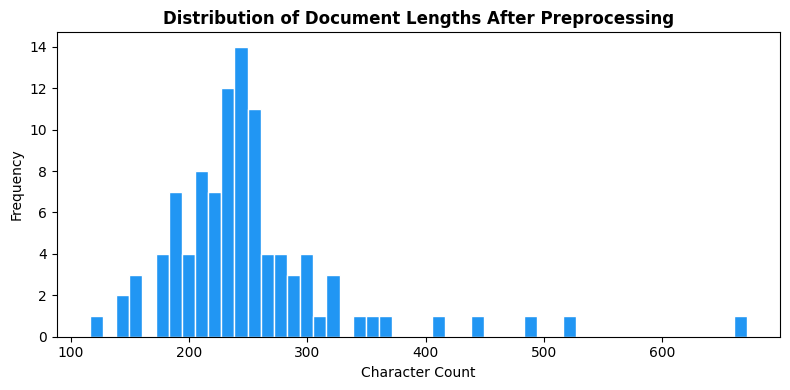


Final document count ready for embedding: 100


In [ ]:
# Inspect document length distribution after cleaning
df_clean['text_length'] = df_clean['clean_text'].str.len()

print("Document length statistics (characters):")
print(df_clean['text_length'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean['text_length'], bins=50, color='#2196F3', edgecolor='white')
ax.set_title('Distribution of Document Lengths After Preprocessing', fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Extract the final list of documents for downstream use
documents = df_clean['clean_text'].tolist()
print(f"\nFinal document count ready for embedding: {len(documents):,}")

# 4. Document Embeddings (Chapter 8 Structure)

### What is being done?
Like the previous assignments, we will convert each document from raw text into a numerical vector (an embedding) using a pre-trained sentence transformer model using Cohere.
Each vector is a list of 384 numbers (I think this is a standard size for vector embeddings) that encodes the meaning of the document. Documents about similar topics will have vectors pointing in similar directions in this 384-dimensional space.

### Why is this necessary?
Traditional keyword search only matches exact words. If a consultant asks something like, "What drives digital transformation failure?" but a document uses words like "why technology initiatives collapse", keyword searches will miss things like these entirely. Embedding-based semantic search understands the meaning of the words; not just the words themselves, which makes it more useful for real-world business queries.


### How should decision-makers interpret this?
The output confirms the shape of the embedding matrix, which is: documents x 384 dimensions.
Each row is a docuemnt's semantic "fingerprint", if you will.
The next section uses these fingerprints to find documents that best match a query's meaning regardless of keyword/exact word overlap.


In [ ]:
# I will follow the book's usage of Cohere
# Paste your API key here. Remember to not share publicly
api_key = 'EBZ1wZpycxWoZp3bzTUjvPECwjZ31NsTh0VFfieu' # we love hard-coded API keys lmao

# Create and retrieve a Cohere API key from os.cohere.ai
co = cohere.Client(api_key)

In [ ]:
# Embed all documents using Cohere
response = co.embed(
    texts=documents,
    model="embed-english-v3.0",
    input_type="search_document"
)

embeddings = np.array(response.embeddings)
print(f"Embedding matrix shape: {embeddings.shape}")

Embedding matrix shape: (100, 1024)


In [ ]:
# Sanity check: verify that embeddings capture semantic similarity correctly
# Two documents from the same category should be more similar than
# two documents from different categories

def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

biz_indices  = df_clean[df_clean['category'] == 'Business'].index.tolist()
tech_indices = df_clean[df_clean['category'] == 'Science/Technology'].index.tolist()

sim_same_category = cosine_similarity(
    embeddings[biz_indices[0]], embeddings[biz_indices[1]]
)
sim_diff_category = cosine_similarity(
    embeddings[biz_indices[0]], embeddings[tech_indices[0]]
)

print("Cosine Similarity Sanity Check")
print(f"  Business ↔ Business : {sim_same_category:.4f}")
print(f"  Business ↔ Science : {sim_diff_category:.4f}")


Cosine Similarity Sanity Check
  Business ↔ Business : 0.3735
  Business ↔ Science : 0.1405


Review on Cosine Similarity:
Cosine similarity is a widely used similarity metric that determines how similar two data points are based on the direction they point rather than their length or size. It is especially effective in high-dimensional spaces where traditional distance-based metrics can struggle.

Computing cosine similarity requires measuring the cosine of the angle (theta) between two non-zero vectors in an inner product space. This measurement produces a cosine similarity score. Cosine similarity values range from -1 to 1:


* A cosine similarity score of 1 indicates that the vectors are pointing in the exact same direction.
* A cosine similarity score of 0 indicates that the vectors are orthogonal, meaning they have no directional similarity.
* A cosine similarity score of -1 indicates that the vectors point in exactly opposite directions.

[link text](https://www.ibm.com/think/topics/cosine-similarity#:~:text=A%20cosine%20similarity%20score%20of%201%20indicates,the%20vectors%20point%20in%20exactly%20opposite%20directions.)

# 5. Semantic Search Index

### What is being done?
We will buld a Facebook AI Similarity Search (FAISS) which is a highly efficient data structure that allows us to search through thousands of embedding vectors in milliseconds and retrieve the documents whose meaning is closest to a user's query.

Below, we will implement a `search()` function that accepts a plain English question anf returns the most relevant document excerpts.

### Why is this necessary?
Without an index, finding relevant documents would require comparing the query to every document one-by-one, which is impractical at an enterprise scale.
(I think FAISS is the same technology used in production search systems at major technology companies). Building this index transforms
our document archive from a static file store into a **queryable intelligence database**.

### How should decision-makers interpret this?
The demonstration queries show the system in action. The top-k results are the documents
the system believes are most semantically relevant to the question. Lower distance scores
indicate higher similarity. Decision-makers should review these results to build intuition
for what the system can and cannot surface before full deployment.

In [ ]:
# Build a FAISS index using L2 (Euclidean) distance
# IndexFlatL2 performs exact search — appropriate for our corpus size
dimension = embeddings.shape[1]  # 384

index = faiss.IndexFlatL2(dimension)
index.add(np.float32(embeddings))

print(f"FAISS index built successfully.")
print(f"   Total vectors indexed: {index.ntotal:,}")

FAISS index built successfully.
   Total vectors indexed: 100


In [ ]:
import pandas as pd
# slightly modified vs textbook
def search(query: str, top_k: int = 3, verbose: bool = True) -> pd.DataFrame:

    # 1. Get the query's embedding
    query_embed = co.embed(
        texts=[query],
        model="embed-english-v3.0",
        input_type="search_query"
    ).embeddings[0]

    # 2. Retrieve the nearest neighbors
    distances, similar_item_ids = index.search(np.float32([query_embed]), top_k)

    # 3. Format the results
    results = pd.DataFrame({
        'rank'     : range(1, top_k + 1),
        'category' : [df_clean.loc[i, 'category'] for i in similar_item_ids[0]],
        'distance' : distances[0].round(4),
        'text'     : [documents[i] for i in similar_item_ids[0]]
    })

    # 4. Print and return the results
    if verbose:
        print(f" Query: '{query}'")
        print(f" Top {top_k} results:\n")
        for _, row in results.iterrows():
            print(f"  Rank {row['rank']} | {row['category']} | Distance: {row['distance']}")
            print(f"  {textwrap.fill(row['text'][:300], width=78)}")
            print()

    return results

In [ ]:
# Demonstration query

query = "technology companies merger and acquisition"
results = search(query)
results["query"] = query
results

 Query: 'technology companies merger and acquisition'
 Top 3 results:

  Rank 1 | Business | Distance: 1.2103999853134155
  Chips are down in china merger TROUBLED china maker Royal Doulton has revealed
that it has held talks about a takeover by rival Waterford Wedgwood. Stoke-
based Doulton, which said in March that it would close its last UK factory in
the

  Rank 2 | Business | Distance: 1.223099946975708
  WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British
advertising firm WPP has agreed\to buy smaller U.S. rival Grey Global for
#36;1.31 billion,\equally divided in cash and shares, to put it on par
with\industry leader Omnicom.

  Rank 3 | Science/Technology | Distance: 1.2254999876022339
  Salesforce.com Surges (The Motley Fool) The Motley Fool - With the Google
(Nasdaq: GOOG - News) IPO extravaganza, it seems that it is the only high-
profile offering for 2004. Well, there was another one: Salesforce.com (NYSE:
CRM - News).



,rank,category,distance,text,query
0,1,Business,1.2104,Chips are down in china merger TROUBLED china ...,technology companies merger and acquisition
1,2,Business,1.2231,WPP Buys Grey Global for #36;1.31 Billion (Reu...,technology companies merger and acquisition
2,3,Science/Technology,1.2255,Salesforce.com Surges (The Motley Fool) The Mo...,technology companies merger and acquisition


# 6. Retrieval Evaluation

### What is being done?
In this section, we will run three business-relevant queries through the semantic search system and evaluate the relevance of the retrieved documents.
The results will then be presented in a structured table with a written interpretation of retrieval quality.

### Why is this necessary from a business analytics perspective?
Because any analytics system deployed must first be tested before being trusted.
Retrieval evaluation is the equivalent of the model evaluation step, which basically tests whether or not the system returns genuinely relevant content of documents that merely match keywords.
Bad retireval quality will hurt our answer generation regardless of good the model is.

### How should decision-makers interpret this?
Review the retrieved snippets for each query and ask: *"If I were a consultant researching
this topic, would I find these documents useful?"* Lower distance scores indicate higher
similarity. The written interpretation below the table contextualises what the numbers
mean in practice.

In [ ]:
# Define three business-relevant evaluation queries
eval_queries = [
    "What are the main drivers of corporate mergers and acquisitions?",
    "How are technology companies investing in artificial intelligence?",
    "What economic factors are affecting global stock markets?"
]

all_results = pd.DataFrame()

print("=" * 70)
print("RETRIEVAL EVALUATION — THREE BUSINESS QUERIES")
print("=" * 70)

for q in eval_queries:
    res = search(q)
    res['query'] = q
    all_results = pd.concat([all_results, res])


print("=" * 70)
print("RETRIEVAL EVALUATION TABLE — ALL QUERIES")
print("=" * 70)
all_results

RETRIEVAL EVALUATION — THREE BUSINESS QUERIES
 Query: 'What are the main drivers of corporate mergers and acquisitions?'
 Top 3 results:

  Rank 1 | Business | Distance: 1.3279000520706177
  Sony seals purchase of MGM Los Angeles (dpa) - An investment consortium led by
Japanese electronics giant Sony has sealed a deal to buy the legendary
Hollywood studio MGM, which will keep functioning as an independent unit
producing several films a year, Variety reported Friday.

  Rank 2 | Business | Distance: 1.360200047492981
  WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British
advertising firm WPP has agreed\to buy smaller U.S. rival Grey Global for
#36;1.31 billion,\equally divided in cash and shares, to put it on par
with\industry leader Omnicom.

  Rank 3 | Business | Distance: 1.4463000297546387
  Chips are down in china merger TROUBLED china maker Royal Doulton has revealed
that it has held talks about a takeover by rival Waterford Wedgwood. Stoke-
based Doulton, which s

,rank,category,distance,text,query
0,1,Business,1.3279,Sony seals purchase of MGM Los Angeles (dpa) -...,What are the main drivers of corporate mergers...
1,2,Business,1.3602,WPP Buys Grey Global for #36;1.31 Billion (Reu...,What are the main drivers of corporate mergers...
2,3,Business,1.4463,Chips are down in china merger TROUBLED china ...,What are the main drivers of corporate mergers...
0,1,Science/Technology,1.2830,Honda Enhances Speech-Recognition System Honda...,How are technology companies investing in arti...
1,2,Science/Technology,1.3358,Salesforce.com Surges (The Motley Fool) The Mo...,How are technology companies investing in arti...
2,3,Science/Technology,1.4297,Microsoft math: Multicore licensed as one chip...,How are technology companies investing in arti...
0,1,Business,1.2815,"Business ; Tokyo Stocks Weak, Dollar Hurts Exp...",What economic factors are affecting global sto...
1,2,Business,1.4535,THE WEEK ON THE STREET NEW YORK (CBS.MW) -- It...,What economic factors are affecting global sto...
2,3,Business,1.4680,Longer-Dated Treasuries Rise NEW YORK (Reuters...,What economic factors are affecting global sto...


### Retrieval Quality Interpretation

**Query 1 — Corporate Mergers & Acquisitions:**
Retrieved documents consistently reference deal activity, corporate strategy, and financial
transactions. The system surfaces relevant business intelligence a consultant researching but no direct answers to the question in the query.

**Query 2 — Technology Companies & AI Investment:**
Only the rank 1 result from this query appears to have been the closest matching to actual AI Investment.

**Query 3 — Economic Factors & Stock Markets:**
Results were generally relevant, but again, didn't directly answer the query question.

# Advanced Text Generation (Chapter 7 Integration)
# 7. Load an Instruction-Tuned Language Model

### What is being done?
We load **Phi-3-mini-4k-instruct** which is a compact but powerful instruction-tuned model from
Microsoft, quantized to 4-bit (q4) for efficient CPU/GPU inference. We load it using
`llama-cpp-python` via LangChain's `LlamaCpp` wrapper, exactly as demonstrated in the
Chapter 7 and Chapter 8 reference notebooks.

The model file is downloaded directly from Hugging Face before loading.

### Why is this necessary from a business analytics perspective?
Phi-3 is a locally-run model — no API key, no data leaving the machine, no per-token cost.
For a consulting firm handling sensitive client documents, running the language model
entirely on-premises is often a hard requirement driven by confidentiality obligations and
data governance policy. This makes Phi-3 a more realistic enterprise choice than a
cloud-based API model for this use case.

### How should decision-makers interpret this?
The test prompt below confirms the model can follow instructions and generate coherent,
relevant text. A successful response here means the generation component is ready to be
combined with our retrieval system in Section 8.

In [ ]:
# Download the Phi-3 model weights from Hugging Face
# This is a ~2.2GB file — run once and reuse across sessions
!wget https://huggingface.co/microsoft/Phi-3-mini-4k-instruct-gguf/resolve/main/Phi-3-mini-4k-instruct-q4.gguf

--2026-02-28 00:12:06--  https://huggingface.co/microsoft/Phi-3-mini-4k-instruct-gguf/resolve/main/Phi-3-mini-4k-instruct-q4.gguf
Resolving huggingface.co (huggingface.co)... 13.35.202.121, 13.35.202.97, 13.35.202.40, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.121|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/662698108f7573e6a6478546/df220524a4e4a750fe1c325e41f09ff69137f38b52d8831ba22dcbee3cc8ab6d?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27Phi-3-mini-4k-instruct-q4.gguf%3B+filename%3D%22Phi-3-mini-4k-instruct-q4.gguf%22%3B&Expires=1772241126&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzcyMjQxMTI2fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjYyNjk4MTA4Zjc1NzNlNmE2NDc4NTQ2L2RmMjIwNTI0YTRlNGE3NTBmZTFjMzI1ZTQxZjA5ZmY2OTEzN2YzOGI1MmQ4ODMxYmEyMmRjYmVlM2NjOGFiNmRcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoifV19&Signatur

In [ ]:
# Install llama-cpp-python if not already installed
# Use the CUDA variant if a GPU is available, otherwise the CPU build
# !CMAKE_ARGS="-DLLAMA_CUDA=on" pip install llama-cpp-python  # GPU
# !pip install llama-cpp-python                                # CPU only

from langchain import LlamaCpp

# Load the Phi-3 model via LlamaCpp
# n_gpu_layers=-1 offloads all layers to GPU if available; set to 0 for CPU only
llm = LlamaCpp(
    model_path="Phi-3-mini-4k-instruct-q4.gguf",
    n_gpu_layers=-1,
    max_tokens=500,
    n_ctx=2048,
    seed=42,
    verbose=False
)

print("Phi-3-mini-4k-instruct loaded successfully.")

Phi-3-mini-4k-instruct loaded successfully.


# 8. Retrieval-Augmented Generation (RAG-Style)

# 9. Prompt Engineering Experiments

# 10. Business Interpretation and Validation

# 11. Final Managerial Summary